# Statistical Analysis

## Objective

The objective of this notebook is to statistically determine whether the motion sensor measurements differ significantly across the four driving behavior classes.

Instead of relying only on visual inspection, formal hypothesis testing is used to validate whether observed differences are statistically significant.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

raw_df = pd.read_csv("../data/sensor_raw.csv")

## One-Way ANOVA

One-Way ANOVA (Analysis of Variance) is used to determine whether the means of multiple groups are statistically different.

Null Hypothesis (H₀):
The mean sensor value is the same across all driving behavior classes.

Alternative Hypothesis (H₁):
At least one driving behavior class has a different mean.

## Create Motion Intensity Features

### Instead of testing six columns separately, we'll create two meaningful measures.

In [2]:
raw_df["Acceleration_Intensity"] = (
    raw_df["AccX"].abs()
    + raw_df["AccY"].abs()
    + raw_df["AccZ"].abs()
)

raw_df["Rotation_Intensity"] = (
    raw_df["GyroX"].abs()
    + raw_df["GyroY"].abs()
    + raw_df["GyroZ"].abs()
)

## Visualize Motion Intensity

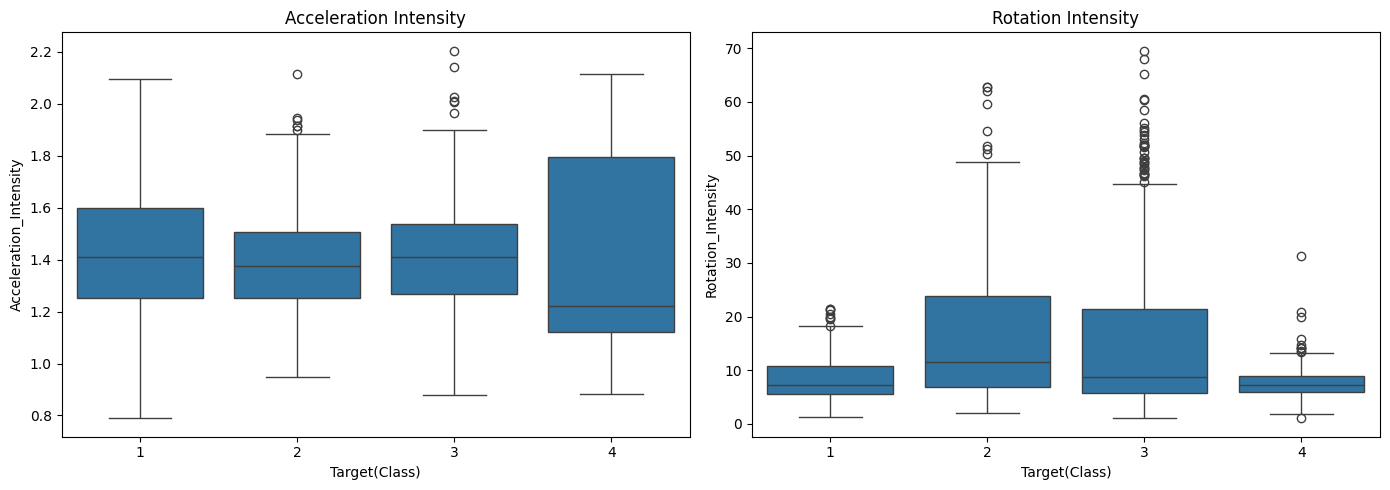

In [3]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(
    data=raw_df,
    x="Target(Class)",
    y="Acceleration_Intensity",
    ax=axes[0]
)

axes[0].set_title("Acceleration Intensity")

sns.boxplot(
    data=raw_df,
    x="Target(Class)",
    y="Rotation_Intensity",
    ax=axes[1]
)

axes[1].set_title("Rotation Intensity")

plt.tight_layout()

plt.savefig(
    "../reports/figures/anova_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The boxplots provide a visual comparison of acceleration and rotational motion across the four driving behavior classes. These differences will now be verified using statistical hypothesis testing.

## ANOVA on Acceleration

In [4]:
groups = []

for cls in sorted(raw_df["Target(Class)"].unique()):
    groups.append(
        raw_df.loc[
            raw_df["Target(Class)"] == cls,
            "Acceleration_Intensity"
        ]
    )

f_stat, p_value = f_oneway(*groups)

print("F Statistic :", round(f_stat,4))
print("P Value :", p_value)

F Statistic : 0.9533
P Value : 0.4140985200808639


#### Interpretation

In [5]:
if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


### Interpretation

If the p-value is greater than 0.05, the observed differences in acceleration intensity across the driving behavior classes are not statistically significant.

## ANOVA on Rotation

In [6]:
groups = []

for cls in sorted(raw_df["Target(Class)"].unique()):
    groups.append(
        raw_df.loc[
            raw_df["Target(Class)"] == cls,
            "Rotation_Intensity"
        ]
    )

f_stat, p_value = f_oneway(*groups)

print("F Statistic :", round(f_stat,4))
print("P Value :", p_value)

F Statistic : 48.4694
P Value : 1.9424559100434382e-29


#### Interpretation



In [7]:
if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


### Interpretation

If the p-value is below 0.05, the rotational motion differs significantly across the driving behavior classes, suggesting that gyroscope measurements provide valuable information for distinguishing driving behavior.

# Statistical Summary

The statistical analysis produced the following findings:

- Acceleration intensity did not show statistically significant differences between the four driving behavior classes.

- Rotation intensity showed statistically significant differences across the driving behavior classes.

These findings indicate that rotational movement is a stronger indicator of driving behavior than acceleration alone.

The results obtained through hypothesis testing support the observations made during the exploratory data analysis and provide statistical justification for using gyroscope-related features in machine learning models.